In [12]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [5]:
df = pd.read_csv("../datasets/EVProject_dataset.csv")
print(df.shape)
df.head()

(149084, 30)


,Timestamp,SoC,SoH,Battery_Voltage,Battery_Current,Battery_Temperature,Charge_Cycles,Motor_Temperature,Motor_Vibration,Motor_Torque,...,Load_Weight,Driving_Speed,Distance_Traveled,Idle_Time,Route_Roughness,RUL,Failure_Probability,Maintenance_Type,TTF,Component_Health_Score
0,2020-01-01 00:00:00,0.826099,0.941338,210.163881,-22.753095,27.149201,149.190930,48.496049,0.369095,113.435589,...,741.754518,103.421162,66.232383,0.520922,0.225970,260.503381,0,1,111.116697,0.852745
1,2020-01-01 00:15:00,0.064728,0.916059,364.000102,-27.701120,53.655101,171.702388,57.829492,1.449195,105.587160,...,769.134035,46.041935,3.146238,0.844005,0.204350,212.813954,0,2,179.229425,0.827616
2,2020-01-01 00:30:00,0.873643,0.908020,388.855089,-36.646406,29.559090,191.617645,46.518363,1.859045,119.610302,...,917.262931,59.588422,79.909148,0.992405,0.175125,273.394511,0,1,171.852663,0.876887
3,2020-01-01 00:45:00,0.853009,0.916476,370.570602,-37.609429,29.690283,111.881817,54.163681,0.381500,182.535625,...,600.598736,44.222285,0.774000,0.007615,0.213264,229.508442,0,0,165.221328,0.816290
4,2020-01-01 01:00:00,0.947540,0.913206,390.011904,-14.275808,28.864338,163.774377,42.075978,0.433927,173.298044,...,613.153029,41.374684,2.872124,0.771938,0.770257,257.302631,1,0,176.890659,0.744260


In [6]:
features = [
    "SoC",
    "SoH",
    "Battery_Voltage",
    "Battery_Current",
    "Battery_Temperature",
    "Charge_Cycles",
    "Motor_Temperature",
    "Motor_Vibration",
    "Power_Consumption",
    "Ambient_Temperature",
    "Load_Weight",
    "Driving_Speed",
    "Distance_Traveled"
]

X = df[features]

y = df["RUL"]

In [7]:
split_idx = int(len(df) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

In [26]:
X_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 119267 entries, 0 to 119266
Data columns (total 25 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   SoC                   119267 non-null  float64
 1   SoH                   119267 non-null  float64
 2   Battery_Voltage       119267 non-null  float64
 3   Battery_Current       119267 non-null  float64
 4   Battery_Temperature   119267 non-null  float64
 5   Charge_Cycles         119267 non-null  float64
 6   Motor_Temperature     119267 non-null  float64
 7   Motor_Vibration       119267 non-null  float64
 8   Motor_Torque          119267 non-null  float64
 9   Motor_RPM             119267 non-null  float64
 10  Power_Consumption     119267 non-null  float64
 11  Brake_Pad_Wear        119267 non-null  float64
 12  Brake_Pressure        119267 non-null  float64
 13  Reg_Brake_Efficiency  119267 non-null  float64
 14  Tire_Pressure         119267 non-null  float64
 15  Tire_Temper

In [8]:
pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),

    (
        "model",
        RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        )
    )
])

pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['SoC','SoH','Battery_Voltage',...,'Load_Weight','Driving_Speed', 'Distance_Traveled']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object d

In [9]:
y_pred = pipeline.predict(X_test)

In [13]:
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)

print("MAE :", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 63.115284499341456
MSE: 7397.1128317467155
RMSE: 86.00646970866038
R2  : -0.03282157526655172


In [14]:
df["RUL"].describe()

count    149084.000000
mean        216.326154
std          84.653478
min           0.000148
25%         211.659783
50%         241.173600
75%         270.561086
max         299.999891
Name: RUL, dtype: float64

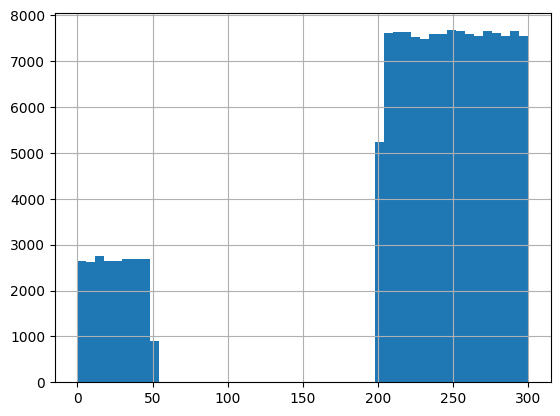

In [15]:
import matplotlib.pyplot as plt

df["RUL"].hist(bins=50)

plt.show()

In [18]:
df["RUL"].nunique()

149084

In [19]:
all_features = [
    "SoC",
    "SoH",
    "Battery_Voltage",
    "Battery_Current",
    "Battery_Temperature",
    "Charge_Cycles",
    "Motor_Temperature",
    "Motor_Vibration",
    "Motor_Torque",
    "Motor_RPM",
    "Power_Consumption",
    "Brake_Pad_Wear",
    "Brake_Pressure",
    "Reg_Brake_Efficiency",
    "Tire_Pressure",
    "Tire_Temperature",
    "Suspension_Load",
    "Ambient_Temperature",
    "Ambient_Humidity",
    "Load_Weight",
    "Driving_Speed",
    "Distance_Traveled",
    "Idle_Time",
    "Route_Roughness",
    "Maintenance_Type"
]

X = df[all_features]
y = df["RUL"]

In [20]:
split_idx = int(len(df) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),

    (
        "model",
        RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        )
    )
])

pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](25,)","['SoC','SoH','Battery_Voltage',...,'Idle_Time','Route_Roughness', 'Maintenance_Type']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,25
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object da

In [22]:
y_pred = pipeline.predict(X_test)

In [23]:
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)

print("MAE :", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 63.38117948558703
MSE: 7418.352428565951
RMSE: 86.12985793884691
R2  : -0.03578715309993585


In [24]:
df[[
    "RUL",
    "TTF",
    "Component_Health_Score",
    "Failure_Probability"
]].corr()

,RUL,TTF,Component_Health_Score,Failure_Probability
RUL,1.000000,0.002175,0.002389,0.001720
TTF,0.002175,1.000000,0.001149,-0.000754
Component_Health_Score,0.002389,0.001149,1.000000,-0.001301
Failure_Probability,0.001720,-0.000754,-0.001301,1.000000


In [28]:
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor
)

In [29]:
models = {
    "Linear Regression":
        LinearRegression(),

    "Random Forest":
        RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ),

    "Extra Trees":
        ExtraTreesRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ),

    "Gradient Boosting":
        GradientBoostingRegressor(
            n_estimators=200,
            random_state=42
        )
}

In [30]:
results = []

for name, model in models.items():

    print(f"Training {name}...")

    model.fit(
        X_train,
        y_train
    )

    y_pred = model.predict(
        X_test
    )

    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    mse = mean_squared_error(
        y_test,
        y_pred
    )

    rmse = mse ** 0.5

    r2 = r2_score(
        y_test,
        y_pred
    )

    results.append([
        name,
        mae,
        rmse,
        r2
    ])

Training Linear Regression...
Training Random Forest...
Training Extra Trees...
Training Gradient Boosting...


In [31]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "RMSE",
        "R2"
    ]
)

results_df.sort_values(
    by="R2",
    ascending=False
)

,Model,MAE,RMSE,R2
0,Linear Regression,59.311915,84.633742,-0.000115
3,Gradient Boosting,59.377401,84.694346,-0.001548
2,Extra Trees,62.833885,85.413590,-0.018631
1,Random Forest,63.123053,85.865362,-0.029435


### Let's save our model

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression

pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "model",
        LinearRegression()
    )
])

pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](25,)","['SoC','SoH','Battery_Voltage',...,'Idle_Time','Route_Roughness', 'Maintenance_Type']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,25
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object da

In [33]:
import joblib

joblib.dump(
    pipeline,
    "../saved_models/rul_model.pkl"
)

print("RUL Model Saved Successfully")

RUL Model Saved Successfully
